
Ga_R1s(r) =
+339.6950 * exp(-31.7059 r)
+234.2876 * r * exp(-26.8956 r)
-0.6745 * r * exp(-13.9060 r)
+1161.7206 * r^2 * exp(-39.0025 r)
-0.3255 * r^2 * exp(-10.3974 r)
-0.0054 * r^2 * exp(-7.0296 r)
-0.0006 * r^2 * exp(-4.7718 r)
+22.7699 * r^3 * exp(-16.3515 r)
-0.0000 * r^3 * exp(-2.8372 r)
+0.0000 * r^3 * exp(-1.8235 r)
+0.0000 * r^3 * exp(-1.2004 r)

Ga_R2s(r) =
-105.2792 * exp(-31.7059 r)
-903.7995 * r * exp(-26.8956 r)
+832.0927 * r * exp(-13.9060 r)
-28.2775 * r^2 * exp(-39.0025 r)
+170.7546 * r^2 * exp(-10.3974 r)
-2.4232 * r^2 * exp(-7.0296 r)
+0.3027 * r^2 * exp(-4.7718 r)
+3365.3844 * r^3 * exp(-16.3515 r)
-0.0045 * r^3 * exp(-2.8372 r)
+0.0004 * r^3 * exp(-1.8235 r)
-0.0000 * r^3 * exp(-1.2004 r)

Ga_R3s(r) =
-40.1559 * exp(-31.7059 r)
-406.2573 * r * exp(-26.8956 r)
+379.5111 * r * exp(-13.9060 r)
-102.1739 * r^2 * exp(-39.0025 r)
+150.6162 * r^2 * exp(-10.3974 r)
-247.2387 * r^2 * exp(-7.0296 r)
-57.3105 * r^2 * exp(-4.7718 r)
+3795.9277 * r^3 * exp(-16.3515 r)
-0.0898 

/tmp/ipykernel_7038/1208956402.py:147: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)


Norm 1s = 0.9999954833370273
Norm 2s = 0.999998264556031
Norm 2p = 0.9999981816341316
Norm 3s = 1.0000002090233917
Norm 3p = 0.9999995053671571
Norm 3d = 1.0000006045526284
Norm 4s = 0.9999999761824795
Norm 4p = 1.0000001736004722
           Q  J_1s_one_electron  J_2s_one_electron  J_3s_one_electron  \
0       0.00           0.028070           0.104205       2.846499e-01   
1       0.05           0.028070           0.104194       2.843887e-01   
2       0.10           0.028069           0.104159       2.836068e-01   
3       0.15           0.028068           0.104101       2.823092e-01   
4       0.20           0.028066           0.104021       2.805042e-01   
...      ...                ...                ...                ...   
1996   99.80           0.000018           0.000002       2.857362e-07   
1997   99.85           0.000018           0.000002       2.849213e-07   
1998   99.90           0.000018           0.000002       2.841090e-07   
1999   99.95           0.000018        

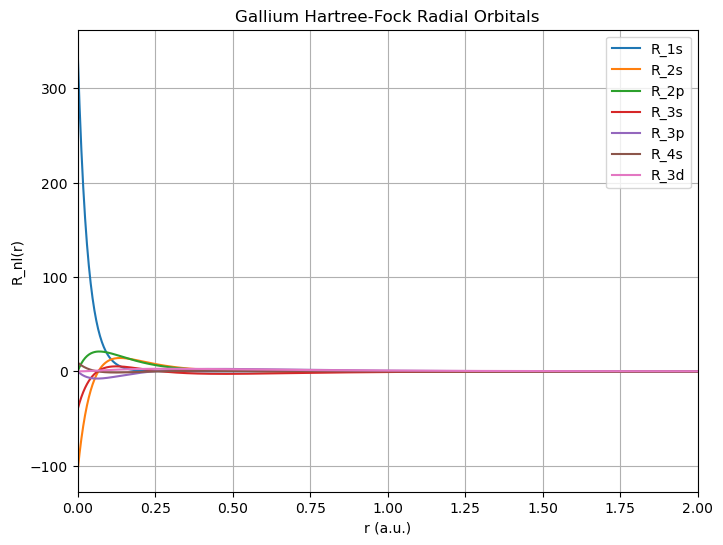

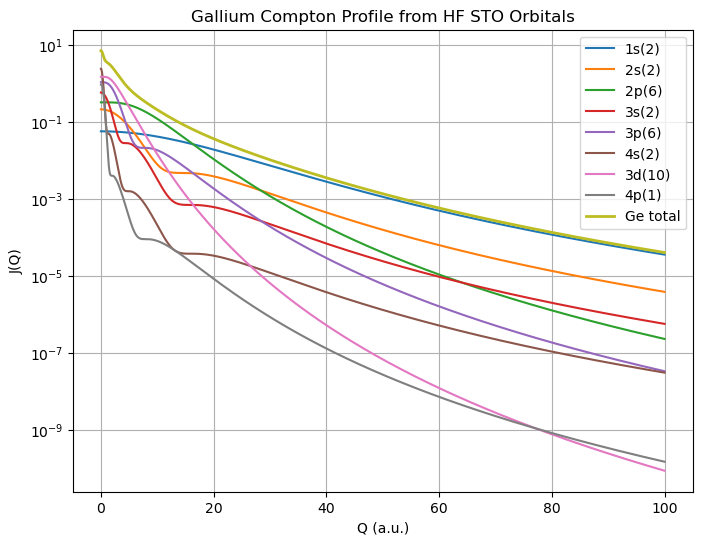

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Gallium Hartree-Fock STO data
# Ga: 1s2 2s2 2p6 3s2 3p6 3d10 4s2 4p1
# Format: (n_j, Z_j, C_j)
# =====================================================

gallium_1s = [
    (1, 31.7059,  0.951369),
    (2, 26.8956,  0.054085),
    (2, 13.9060, -0.000810),
    (3, 39.0025,  0.007436),
    (3, 10.3974, -0.000213),
    (3,  7.0296, -0.000014),
    (3,  4.7718, -0.000006),
    (4, 16.3515,  0.000699),
    (4,  2.8372, -0.000002),
    (4,  1.8235,  0.000001),
    (4,  1.2004,  0.000000),
]

gallium_2s = [
    (1, 31.7059, -0.294851),
    (2, 26.8956, -0.208641),
    (2, 13.9060,  0.999302),
    (3, 39.0025, -0.000181),
    (3, 10.3974,  0.111737),
    (3,  7.0296, -0.006240),
    (3,  4.7718,  0.003025),
    (4, 16.3515,  0.103312),
    (4,  2.8372, -0.000369),
    (4,  1.8235,  0.000210),
    (4,  1.2004, -0.000070),
]

gallium_3s = [
    (1, 31.7059, -0.112463),
    (2, 26.8956, -0.093784),
    (2, 13.9060,  0.455774),
    (3, 39.0025, -0.000654),
    (3, 10.3974,  0.098559),
    (3,  7.0296, -0.636679),
    (3,  4.7718, -0.572674),
    (4, 16.3515,  0.116529),
    (4,  2.8372, -0.007303),
    (4,  1.8235,  0.001607),
    (4,  1.2004, -0.000434),
]

gallium_4s = [
    (1, 31.7059,  0.026164),
    (2, 26.8956,  0.022235),
    (2, 13.9060, -0.108184),
    (3, 39.0025,  0.000156),
    (3, 10.3974, -0.029450),
    (3,  7.0296,  0.186235),
    (3,  4.7718,  0.144131),
    (4, 16.3515, -0.029905),
    (4,  2.8372, -0.313648),
    (4,  1.8235, -0.554658),
    (4,  1.2004, -0.262151),
]

gallium_2p = [
    (2, 30.9647,  0.079671),
    (2, 11.6838,  0.667452),
    (3, 25.4398,  0.175535),
    (3,  8.2598,  0.015771),
    (3,  5.5111,  0.000196),
    (3,  3.7958,  0.000646),
    (4, 20.5257,  0.119573),
    (4,  2.2879, -0.000029),
    (4,  1.3751,  0.000015),
    (4,  0.8682, -0.000006),
]

gallium_3p = [
    (2, 30.9647, -0.015325),
    (2, 11.6838, -0.422019),
    (3, 25.4398, -0.025182),
    (3,  8.2598,  0.273334),
    (3,  5.5111,  0.616186),
    (3,  3.7958,  0.285565),
    (4, 20.5257,  0.000699),
    (4,  2.2879,  0.003673),
    (4,  1.3751,  0.000157),
    (4,  0.8682,  0.000039),
]

gallium_4p = [
    (2, 30.9647, -0.002333),
    (2, 11.6838, -0.071040),
    (3, 25.4398, -0.003629),
    (3,  8.2598,  0.048418),
    (3,  5.5111,  0.123582),
    (3,  3.7958,  0.025765),
    (4, 20.5257,  0.000350),
    (4,  2.2879, -0.265238),
    (4,  1.3751, -0.533374),
    (4,  0.8682, -0.331517),
]

gallium_3d = [
    (3, 15.7448,  0.016981),
    (3,  8.5680,  0.230981),
    (3,  5.2654,  0.423088),
    (3,  3.1808,  0.376129),
    (3,  1.9710,  0.104017),
]
# =====================================================
# STO normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================
def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R
# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 1000.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)
        chi.append(val)

    return np.array(chi)

# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Build Krypton radial orbitals
# =====================================================
def print_R_formula(coeffs, name):
    print(f"\n{name}(r) =")

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N

        if n == 1:
            print(f"{A:+.4f} * exp(-{Z:.4f} r)")
        elif n == 2:
            print(f"{A:+.4f} * r * exp(-{Z:.4f} r)")
        elif n == 3:
            print(f"{A:+.4f} * r^2 * exp(-{Z:.4f} r)")
        elif n == 4:
            print(f"{A:+.4f} * r^3 * exp(-{Z:.4f} r)")
R1s = R_nl(r, gallium_1s)
R2s = R_nl(r, gallium_2s)
R3s = R_nl(r, gallium_3s)
R4s = R_nl(r, gallium_4s)
R2p = R_nl(r, gallium_2p)
R3p = R_nl(r, gallium_3p)
R4p = R_nl(r, gallium_4p)
R3d = R_nl(r, gallium_3d)

print_R_formula(gallium_1s, "Ga_R1s")
print_R_formula(gallium_2s, "Ga_R2s")
print_R_formula(gallium_3s, "Ga_R3s")
print_R_formula(gallium_4s, "Ga_R4s")
print_R_formula(gallium_2p, "Ga_R2p")
print_R_formula(gallium_3p, "Ga_R3p")
print_R_formula(gallium_3d, "Ga_R3d")
print_R_formula(gallium_4p, "Ga_R4p")

# =====================================================
# Momentum-space wavefunctions
# =====================================================

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)
chi_3s = chi_p(p, r, R3s, l=0)
chi_4s = chi_p(p, r, R4s, l=0)
chi_2p = chi_p(p, r, R2p, l=1)
chi_3p = chi_p(p, r, R3p, l=1)
chi_4p = chi_p(p, r, R4p, l=1)
chi_3d = chi_p(p, r, R3d, l=2)

# =====================================================
# Momentum densities and Compton profiles
# =====================================================
I_1s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)
I_3s, J_3s = calculate_J(p, chi_3s, Q)
I_4s, J_4s = calculate_J(p, chi_4s, Q)
I_2p, J_2p = calculate_J(p, chi_2p, Q)
I_3p, J_3p = calculate_J(p, chi_3p, Q)
I_4p, J_4p = calculate_J(p, chi_4p, Q)
I_3d, J_3d = calculate_J(p, chi_3d, Q)

print("Norm 1s =", np.trapezoid(I_1s, p))
print("Norm 2s =", np.trapezoid(I_2s, p))
print("Norm 2p =", np.trapezoid(I_2p, p))
print("Norm 3s =", np.trapezoid(I_3s, p))
print("Norm 3p =", np.trapezoid(I_3p, p))
print("Norm 3d =", np.trapezoid(I_3d, p))
print("Norm 4s =", np.trapezoid(I_4s, p))
print("Norm 4p =", np.trapezoid(I_4p, p))

# Krypton has  1s(2) 2s(2) 2p(6) 3s(2) 3p(6) 3d(10) 4s(2) 4p(5)
J_total = 2*J_1s + 2*J_2s + 6*J_2p + 2*J_3s + 6*J_3p + 10*J_3d + 2*J_4s + 1*J_4p

# =====================================================
# Print and save table
# =====================================================
table = pd.DataFrame({
    "Q": Q,
    "J_1s_one_electron": J_1s,
    "J_2s_one_electron": J_2s,
    "J_3s_one_electron": J_3s,
    "J_2p_one_electron": J_2p,
    "J_3p_one_electron": J_3p,
    "J_3d_one_electron": J_3d,
    "J_4s_one_electron": J_4s,
    "J_4p_one electron": J_4p,
    "J_1s(2)": 2*J_1s,
    "J_2s(2)": 2*J_2s,
    "J_2p(6)": 6*J_2p,
    "J_3s(2)": 2*J_3s,
    "J_3p(6)": 6*J_3p,
    "J_4s(1)": 2*J_4s,
    "J_3d(10)": 10*J_3d,
    "J_4p(1)": 1*J_4p,
    "J_total_Ga": J_total
    })
print(table)
table.to_csv("Galium__STO_HF_profile.csv", index = False)

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.plot(r, R2p, label="R_2p")
plt.plot(r, R3s, label="R_3s")
plt.plot(r, R3p, label="R_3p")
plt.plot(r, R4s, label="R_4s")
plt.plot(r, R3d, label="R_3d")
plt.xlim(0, 2)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("Gallium Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================
plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 2*J_2s, label="2s(2)")
plt.plot(Q, 6*J_2p, label="2p(6)")
plt.plot(Q, 2*J_3s, label="3s(2)")
plt.plot(Q, 6*J_3p, label="3p(6)")
plt.plot(Q, 2*J_4s, label="4s(2)")
plt.plot(Q, 10*J_3d, label="3d(10)")
plt.plot(Q, 1*J_4p, label="4p(1)")
plt.plot(Q, J_total, label="Ge total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title("Gallium Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()